# Checking the EPCAPE seasonal-averages table: the rows attributed to Kavin

Lynn asked for an independent check of every value in the EPCAPE seasonal-averages table
(`Table-EPCAPE_SeasonalAverages.xlsx`, sheet *Cloud&MetQuantities*) whose author column names Kavin.
For each of those rows this notebook

1. says which data and which definition reproduce the quantity,
2. computes the five averages: the whole campaign and the four seasons, each as mean ± standard deviation, and
3. sets them next to the sheet's values, with the percentage difference of the means.

**Quality control.** Every ARM variable that has a `qc_<variable>` companion keeps only samples whose QC value is **exactly 0**, meaning the sample passed every test, including those ARM rates "Indeterminate". Variables distributed without a QC field are used as they are; Section 11 lists which ones.

**Seasons** follow the sheet's column headers: Spring = Apr–Jun 2023, Summer = Jul–Sep 2023, Fall = Oct–Dec 2023, Winter = Feb 15–Mar 2023 + Jan–Feb 14 2024, EPCAPE = 2023-02-15 to 2024-02-14 (UTC).
Each statistic is the arithmetic mean ± sample standard deviation over all samples in the season. The campaign value is therefore sample-weighted, not the mean of the four seasons. The kind of sample (5-min mean, radiosonde launch, rain day, …) is printed with every table, because the standard deviation depends on it.

**Where a definition is undocumented** (rain, PBL height), several readings are computed and ranked by how well they reproduce the sheet. The best match is a hypothesis about Kavin's method to confirm with him, not proof of it.

## Running it

Download everything once, from the `EPCAPE` folder (resumable; files already present are skipped):

```bash
python comparisons/seasonal_averages/download_data.py
```

This fetches server-side subsets of the ARM products listed in `config.yaml` (with their `qc_` fields), builds one combined file per time-series product in `<data folder>/processed/`, and downloads the Russell-group files (AMS at Mt. Soledad, GCVI enhancement factors, Low Cloud Periods) from the UC San Diego Library into `<data folder>/processed/Aerosol Quantification Products/`.
The spreadsheet is read from `~/Downloads/Table-EPCAPE_SeasonalAverages.xlsx` unless `EPCAPE_SEASONAL_TABLE` points elsewhere.
Outputs (tables, settings, figure) go to `<data folder>/processed/derived/seasonal_averages_check/`.

In [1]:
# --- Setup: make the EPCAPE package importable -------------------------------
# The EPCAPE folder is itself the Python package (config.yaml and the shared
# modules sit directly in it), so its PARENT folder goes on sys.path.
import json
import os
import sys
from pathlib import Path


def find_repo_root(start: Path = Path.cwd()) -> Path:
    """Walk up from the notebook's folder to the EPCAPE folder (holds config.yaml and __init__.py)."""
    for p in [start, *start.parents]:
        if (p / "config.yaml").is_file() and (p / "__init__.py").is_file():
            return p
    raise FileNotFoundError(f"Could not find the EPCAPE folder above {start}")


REPO = find_repo_root()
if str(REPO.parent) not in sys.path:
    sys.path.insert(0, str(REPO.parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from EPCAPE import qc, units
from EPCAPE.config import active_machine
from EPCAPE.derived import git_revision
from EPCAPE.plotting import INK, INK_2, INK_3, use_style
from EPCAPE.products import load_product
from EPCAPE.comparisons.seasonal_averages import quantities as Q
from EPCAPE.comparisons.seasonal_averages import seasonal as S
from EPCAPE.comparisons.seasonal_averages import sources as SRC

use_style()
pd.set_option("display.width", 220, "display.max_columns", 30, "display.max_colwidth", 90)
MACHINE = active_machine()
GIT_REVISION = git_revision()
print(f"EPCAPE folder: {REPO}\nMachine: {MACHINE.name}   data folder: {MACHINE.data_root}\ngit revision: {GIT_REVISION}")

EPCAPE folder: /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE
Machine: local   data folder: /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/data
git revision: cbf888f-dirty


In [2]:
# --- Settings: every choice that changes a number is set here ---------------
TABLE_XLSX = Path(os.environ.get("EPCAPE_SEASONAL_TABLE", "~/Downloads/Table-EPCAPE_SeasonalAverages.xlsx")).expanduser()
AVG_PERIOD = "5min"  # continuous series are averaged to this grid before statistics (Kavin: 5-min for SW)
SZA_MAX_DEG = 80.0  # SW transmittance: daytime = solar zenith angle <= 80 deg (ratio is noisy near the horizon)
LOW_CLOUD_MAX_M = 3000.0  # "low cloud": top (KAZR) or base (ceilometer) <= 3 km, the EPCAPE Low Cloud Period bound
LWP_CLOUDY_GM2 = 20.0  # cloudy-sky LWP sensitivity test: 5-min LWP >= 20 g m-2, i.e. above the
#                        2-channel MWR retrieval uncertainty of order 20-30 g m-2 (Crewell & Loehnert 2003, Radio Sci. 38, 8042)
LWP_RAIN_WINDOW_MIN = 30.0  # MWR LWP: drop 5-min bins within ±30 min of rain at the Pier Parsivel (wet radome)
RAIN_THRESHOLD_MM_H = 0.1  # a 1-min disdrometer sample is "raining" at >= 0.1 mm/h
RAIN_MAX_GAP_MIN = 60.0  # raining samples closer than 60 min belong to one rain event
RAIN_MIN_MM = 0.1  # minimum accumulation of a rain event / rain day / wet hour
GCVI_MIN_SEGMENT_MIN = 15.0  # "minimum sampling 15 min" (sheet rows 33-34)
CLOSE_PCT = 10.0  # reading aid only: flags |ours - sheet| <= 10 % of the sheet's mean
OUT_DIR = MACHINE.processed_dir() / "derived" / "seasonal_averages_check"

SETTINGS = {
    k: (str(v) if isinstance(v, Path) else v)
    for k, v in dict(globals()).items()
    if k.isupper() and k not in ("REPO", "MACHINE", "GIT_REVISION", "SETTINGS")
}
SETTINGS

{'INK': '#0b0b0b',
 'INK_2': '#52514e',
 'INK_3': '#8a8984',
 'Q': <module 'EPCAPE.comparisons.seasonal_averages.quantities' from '/Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/comparisons/seasonal_averages/quantities.py'>,
 'S': <module 'EPCAPE.comparisons.seasonal_averages.seasonal' from '/Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/comparisons/seasonal_averages/seasonal.py'>,
 'SRC': <module 'EPCAPE.comparisons.seasonal_averages.sources' from '/Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/comparisons/seasonal_averages/sources.py'>,
 'TABLE_XLSX': '/Users/andrewbuggee/Downloads/Table-EPCAPE_SeasonalAverages.xlsx',
 'AVG_PERIOD': '5min',
 'SZA_MAX_DEG': 80.0,
 'LOW_CLOUD_MAX_M': 3000.0,
 'LWP_CLOUDY_GM2': 20.0,
 'LWP_RAIN_WINDOW_MIN': 30.0,
 'RAIN_THRESHOLD_MM_H': 0.1,
 'RAIN_MAX_GAP_MIN': 60.0,
 'RAIN_MIN_MM': 0.1,
 'GCVI_MIN_SEGMENT_MIN': 15.0,
 'CLOSE_PCT': 10.0,
 'OUT_DIR': '/Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/

## The sheet's rows attributed to Kavin

In [3]:
TABLE = S.read_table_rows(TABLE_XLSX)
print(f"{len(TABLE)} rows attributed to Kavin in {TABLE_XLSX.name} (sheet Cloud&MetQuantities)")
display(TABLE[["quantity", "units", "location", "method"] + [f"{s}_raw" for s in S.SEASON_ORDER]])

30 rows attributed to Kavin in Table-EPCAPE_SeasonalAverages.xlsx (sheet Cloud&MetQuantities)


,quantity,units,location,method,EPCAPE_raw,Spring_raw,Summer_raw,Fall_raw,Winter_raw
sheet_row,,,,,,,,,
7,Shortwave (SW) Transmittance,%,Soledad,"SKYRAD, RADFLUX1LONG",0.58 ± 0.29,0.50 ± 0.31,0.56 ± 0.28,0.66 ± 0.24,0.61 ± 0.28
8,Longwave (LW) Flux,W/m2,Soledad,From Lubin,350 ± 30,370 ± 10,380 ± 10,323 ± 5,308 ± 3
10,Liquid Water Path,g/m2,Pier,From Virendra (?),56 ± 127,92 ± 161,59 ± 118,42 ± 100,33 ± 92
15,Cloud Top Height,m,Pier,KAZR,920 ± 380,890 ± 330,774 ± 353,1057 ± 416,1192 ± 397
17,Boundary Layer Height,m,Pier,PBLH-Thermo (Zhang),899 ± 305,886 ± 256,764 ± 206,1014 ± 343,1124 ± 442
18,Boundary Layer Height,m,Pier,PBLH-MPL,790 ±.274,765 ± 255,728 ± 248,844 ± 313,970 ± 288
19,Boundary Layer Height,m,Pier,BL-Depth (Miller),703 ± 275,796 ± 255,679 ± 261,626 + 297,649 ± 272
20,Lifting Condensation Level,m,Pier,Radiosondes,637 ± 483,490 ± 261,361 ± 165,917 ± 676,787 ± 428
21,Cloud Base Height,m,Pier,Ceilometer,661 ± 316,619 ± 270,554 ± 254,836 ± 389,929 ± 362


In [4]:
# --- Bookkeeping shared by every section --------------------------------------
SUMMARY = []  # one comparison table per (sheet row, definition); concatenated in Section 11
QC_INFO = []  # one dict per screened variable: samples before / after QC = 0
NOT_CHECKED = {}  # sheet row -> why it could not be re-derived from available data


def check(sheet_row, values, definition, sample, *, primary=True, show=True, reference=None, quantity=None):
    """Seasonal mean ± std of `values` next to the sheet's (or another reference's) values.

    primary=True marks the definition closest to the sheet's own description;
    the others are sensitivity tests. `sample` names what one value is."""
    stats = S.seasonal_stats(values)
    if reference is None:
        cmp = S.compare(stats, TABLE, sheet_row, definition, close_pct=CLOSE_PCT)
    else:
        cmp = S.compare_to(stats, reference, sheet_row, quantity, definition, close_pct=CLOSE_PCT)
    cmp["sample"] = sample
    cmp["primary"] = primary
    SUMMARY.append(cmp)
    if show:
        tag = "" if primary else "  *(sensitivity test)*"
        display(Markdown(f"**Row {sheet_row}: {definition}**{tag}  \nOne sample = {sample}."))
        display(S.show(cmp))
    return cmp


def compare_candidates(sheet_row, candidates, *, label="", mark_primary=True):
    """Several readings of an undocumented definition, ranked by how well each reproduces the sheet.

    With mark_primary=True the best-matching one is marked primary. Returns
    (ranking, comparisons)."""
    cmps = [
        check(sheet_row, v, f"{label}{name}", sample, primary=False, show=False)
        for name, (v, sample) in candidates.items()
    ]
    ranking = S.closest_definition(cmps)
    if mark_primary:
        best = ranking["definition"].iloc[0]
        for c in cmps:
            c["primary"] = c["definition"].iloc[0] == best
    wide = pd.concat({c["definition"].iloc[0]: c.set_index("season")["ours"] for c in cmps}, axis=1).T
    wide.loc["SHEET (Kavin)"] = cmps[0].set_index("season")["table"]
    display(wide)
    display(ranking.round(2))
    return ranking, cmps

## 0. Consistency checks on the sheet itself (no data needed)

In [5]:
issues = []
# (a) Sampling hours: the four seasons should add up to the campaign total.
for r in (33, 34):
    seas = [TABLE.loc[r, f"{s}_mean"] for s in ("Spring", "Summer", "Fall", "Winter")]
    total = TABLE.loc[r, "EPCAPE_mean"]
    issues.append({
        "sheet_row": r, "check": "seasonal hours add up to the campaign total",
        "found": f"{' + '.join(f'{v:g}' for v in seas)} = {sum(seas):g}  vs  {total:g}",
        "ok": bool(abs(sum(seas) - total) <= 0.02 * total),
    })
# (b) Rows labelled "Mass Fraction": four species' fractions cannot add up to more than 1.
for rows, kind in (((35, 36, 37, 38), "cloud residual"), ((39, 40, 41, 42), "haze residual")):
    for s in S.SEASON_ORDER:
        tot = sum(TABLE.loc[r, f"{s}_mean"] for r in rows)
        issues.append({
            "sheet_row": f"{rows[0]}-{rows[-1]}", "check": f"{kind} 'mass fractions' sum to <= 1 ({s})",
            "found": f"sum = {tot:.2f}", "ok": bool(tot <= 1.0),
        })
# (c) Cells that needed an assumption to read, or whose std is implausibly small (typo?).
for r in TABLE.index:
    for s in S.SEASON_ORDER:
        raw, m, sd, note = (TABLE.loc[r, f"{s}_{k}"] for k in ("raw", "mean", "std", "note"))
        if note and note not in ("empty", "no ± given", "n/a", "std n/a"):
            issues.append({"sheet_row": r, "check": f"cell {S.SEASON_COLUMNS[s]}{r} reads cleanly",
                           "found": f"{raw!r}: {note}", "ok": False})
        if np.isfinite(sd) and np.isfinite(m) and m > 0 and sd < 0.01 * m:
            issues.append({"sheet_row": r, "check": f"cell {S.SEASON_COLUMNS[s]}{r}: std >= 1 % of mean",
                           "found": f"{raw!r}", "ok": False})
ISSUES = pd.DataFrame(issues)
display(ISSUES[~ISSUES["ok"]])

,sheet_row,check,found,ok
1,34,seasonal hours add up to the campaign total,52 + 101 + 500 + 35 = 688 vs 236,False
2,35-38,cloud residual 'mass fractions' sum to <= 1 (EPCAPE),sum = 1.64,False
3,35-38,cloud residual 'mass fractions' sum to <= 1 (Spring),sum = 1.16,False
4,35-38,cloud residual 'mass fractions' sum to <= 1 (Summer),sum = 1.83,False
5,35-38,cloud residual 'mass fractions' sum to <= 1 (Fall),sum = 1.93,False
10,39-42,haze residual 'mass fractions' sum to <= 1 (Fall),sum = 1.01,False
12,8,cell I8: std >= 1 % of mean,'308 ± 3',False
13,18,cell E18: std >= 1 % of mean,'790 ±.274',False
14,19,cell H19 reads cleanly,'626 + 297': '+' read as '±',False


Other things noticed while reading the sheet. These don't need data, but they should be fixed before the table is published:

* **Rows 35–42 are labelled "Mass Fraction"**, but each season's four values add up to more than 1, as listed above. In the cell comment on E35 Lynn asked for **mass concentrations** in the table. The values are concentrations (µg m⁻³), and the labels and the missing units should say so.
* **H34 "5.0\*10^2" h** of fall haze sampling cannot be right. The seasons would then sum to 688 h against E34 = 236 h, and all GCVI sampling in Oct–Dec 2023 amounts to only ~110 h (Section 10). E34 − (F34 + G34 + I34) = 48 h, so the value is presumably 5.0×10¹.
* **Units:** B7 says "%" but the values are fractions (0–1). B25 and B28 say m⁻³, but ~200 is cm⁻³. Rows 26 and 29 (effective diameter) and 35–42 have no units. B55 reads "g/^#3".
* **Typos in values:** E18 "790 ±.274" (presumably ± 274) and H19 "626 + 297" (presumably ±).
* **Rows 22–24 ("Rain Accumulation", mm/hr):** an accumulation is in mm, a rate in mm/hr. Section 8 shows which one the numbers are. "LDS1" refers to a facility that does not exist in ARM's EPCAPE data: the disdrometers were at M1 (Scripps Pier) and S2 (Mt. Soledad).
* **Rows 7–8 say "Soledad"**, but ARM's SKYRAD and RADFLUX data for EPCAPE exist only for M1, the Scripps Pier. ARM Live lists no `epcskyrad*S2`, `epcradflux*S2` or `epcgndrad*S2` files.

## 1. Shortwave transmittance (row 7)

Kavin's note describes the ratio of 5-min-averaged downwelling SW from SKYRAD (`radflux1long` dataset) to an *idealized clear-sky analytical model (Atwater and Ball 1981)*.
Here the numerator is the same quantity: RADFLUX `downwelling_shortwave`, which is the SKYRAD measurement, with QC = 0.
The denominator is **RADFLUX's own clear-sky estimate** (`clearsky_downwelling_shortwave`). That is an empirical fit to this site's clear-sky periods (Long & Ackerman 2000, *JGR* 105, 15609), not the Atwater & Ball model. I could not verify the Atwater & Ball equations from an accessible source, so I did not implement them.
Clear-sky models typically differ by a few percent, which shifts the ratio by about as much.
A sensitivity test below divides by top-of-atmosphere irradiance instead. Together the two bracket how bright the sheet's clear-sky model must be.
`clearsky_downwelling_shortwave` has no QC field. Both numerator and denominator are averaged over the same valid 1-min samples. Only samples with SZA ≤ `SZA_MAX_DEG` are used.

In [6]:
rad = load_product("radflux_M1")
sw_t, info = Q.sw_transmittance(rad, sza_max_deg=SZA_MAX_DEG, period=AVG_PERIOD)
QC_INFO.extend(info["qc"])
check(7, sw_t, f"SW↓ / RADFLUX clear-sky SW↓, 5-min means, SZA ≤ {SZA_MAX_DEG:g}°, QC = 0 (Scripps Pier)",
      "5-min mean (daytime)")

# How much does the daytime cut move the means?
sens = {f"SZA ≤ {z}°": S.seasonal_stats(Q.sw_transmittance(rad, sza_max_deg=z, period=AVG_PERIOD)[0])["mean"]
        for z in (70, 80, 85)}
display(Markdown("Seasonal mean transmittance for three daytime cuts:"))
display(pd.DataFrame(sens).T.round(3))
# Clear-sky ratios scatter around 1.00, so only > 1.05 is counted as cloud-edge enhancement.
print(f"5-min ratios > 1.05 (cloud-edge enhancement): {100 * (sw_t.dropna() > 1.05).mean():.1f} %")

# Bracketing the denominator: SW / top-of-atmosphere SW (clearness index). If the sheet's
# numerator is the same SKYRAD measurement, sheet / clearness index = how bright Kavin's
# clear-sky model is relative to TOA, to set next to RADFLUX's clear-sky / TOA.
kt, _ = Q.sw_clearness_index(rad, sza_max_deg=SZA_MAX_DEG, period=AVG_PERIOD)
kt_cmp = check(7, kt, "SW↓ / TOA SW↓ (clearness index; NOT the sheet's definition)", "5-min mean (daytime)",
               primary=False)
cs_over_toa = S.seasonal_stats(
    Q.sw_clearness_index(rad.assign(downwelling_shortwave=rad["clearsky_downwelling_shortwave"]).drop_vars(
        "qc_downwelling_shortwave", errors="ignore"), sza_max_deg=SZA_MAX_DEG, period=AVG_PERIOD)[0])["mean"]
implied = kt_cmp.set_index("season")["ours_mean"] / kt_cmp.set_index("season")["table_mean"]
display(pd.DataFrame({"RADFLUX clear-sky / TOA": cs_over_toa,
                      "implied sheet clear-sky / TOA": implied}).T.round(3))

**Row 7: SW↓ / RADFLUX clear-sky SW↓, 5-min means, SZA ≤ 80°, QC = 0 (Scripps Pier)**  
One sample = 5-min mean (daytime).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,0.71 ± 0.32,45458,0.58 ± 0.29,21.9,1.10,False
Spring,0.61 ± 0.34,13048,0.50 ± 0.31,22.3,1.08,False
Summer,0.67 ± 0.31,12755,0.56 ± 0.28,19.0,1.10,False
Fall,0.84 ± 0.25,9706,0.66 ± 0.24,27.1,1.04,False
Winter,0.76 ± 0.32,9949,0.61 ± 0.28,23.9,1.13,False


Seasonal mean transmittance for three daytime cuts:

,EPCAPE,Spring,Summer,Fall,Winter
SZA ≤ 70°,0.722,0.634,0.690,0.852,0.768
SZA ≤ 80°,0.707,0.611,0.666,0.839,0.756
SZA ≤ 85°,0.694,0.596,0.652,0.827,0.744


5-min ratios > 1.05 (cloud-edge enhancement): 3.5 %


**Row 7: SW↓ / TOA SW↓ (clearness index; NOT the sheet's definition)**  *(sensitivity test)*  
One sample = 5-min mean (daytime).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,0.53 ± 0.24,45458,0.58 ± 0.29,-9.1,0.84,True
Spring,0.47 ± 0.26,13048,0.50 ± 0.31,-6.8,0.85,True
Summer,0.50 ± 0.24,12755,0.56 ± 0.28,-10.9,0.85,False
Fall,0.61 ± 0.19,9706,0.66 ± 0.24,-7.3,0.79,True
Winter,0.56 ± 0.24,9949,0.61 ± 0.28,-8.1,0.85,True


,EPCAPE,Spring,Summer,Fall,Winter
RADFLUX clear-sky / TOA,0.743,0.755,0.744,0.728,0.740
implied sheet clear-sky / TOA,0.909,0.932,0.891,0.927,0.919


## 2. Downwelling longwave (row 8)

The sheet's source is "From Lubin", which is not an ARM product, at Soledad. The closest ARM data are the RADFLUX/SKYRAD pyrgeometers **at the Scripps Pier**, so this is a comparison with a different instrument ~250 m lower, not a reproduction.
The sheet's standard deviations (3–10 W m⁻² within a season) are far smaller than the spread of 5-min values. The second table shows the statistics of **monthly means**, whose spread is of that size.

In [7]:
lw, info = Q.lw_down(rad, period=AVG_PERIOD)
QC_INFO.extend(info["qc"])
check(8, lw, "RADFLUX downwelling LW, QC = 0 (Scripps Pier, not Soledad)", "5-min mean")
check(8, S.monthly_means(lw), "RADFLUX downwelling LW, monthly means (std across months)", "calendar-month mean",
      primary=False)
del rad

**Row 8: RADFLUX downwelling LW, QC = 0 (Scripps Pier, not Soledad)**  
One sample = 5-min mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,347 ± 41,104540,350 ± 30,-0.9,1.37,True
Spring,355 ± 36,26208,370 ± 10,-4.0,3.56,True
Summer,381 ± 28,26375,380 ± 10,0.2,2.80,True
Fall,332 ± 34,26493,323 ± 5,2.8,6.84,True
Winter,318 ± 36,25464,308 ± 3,3.3,12.03,True


**Row 8: RADFLUX downwelling LW, monthly means (std across months)**  *(sensitivity test)*  
One sample = calendar-month mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,344 ± 28,13,350 ± 30,-1.8,0.93,True
Spring,355 ± 15,3,370 ± 10,-4.0,1.46,True
Summer,380.9 ± 3.4,3,380 ± 10,0.2,0.34,True
Fall,332 ± 18,3,323 ± 5,2.7,3.68,True
Winter,316.6 ± 8.8,4,308 ± 3,2.8,2.93,True


## 3. Liquid water path (row 10)

The sheet's source is "From Virendra (?)", which is not documented.
ARM's standard LWP at the Pier is the MWRRET VAP (`phys_lwp`; Turner et al. 2007, *IEEE TGRS* 45, 3680); MWRLOS (`liq`) is the instrument-level 2-channel retrieval.
Both are **all-sky means**: clear sky (LWP ≈ 0) and small negative values within the retrieval noise are kept.
**Rain screen (primary definition):** 5-min values within ±`LWP_RAIN_WINDOW_MIN` of any rain at the co-located Parsivel (LD M1, QC = 0) are dropped. Liquid on the radiometer's radome emits at 23.8 and 31.4 GHz and makes the retrieved LWP far too high. On the 8 % of 5-min bins near rain, the mean QC = 0 LWP is ~385 g m⁻², against ~63 g m⁻² elsewhere. MWRLOS's own `wet_window` flag is set for ~39 % of all samples (dew and fog on the pier), so it is not used. The unscreened series is kept as a sensitivity test.

**What QC = 0 does here:** MWRRET sets an *Indeterminate* bit when the ceilometer reports no cloud base. Requiring QC = 0 therefore keeps mostly samples with a detected cloud base, which pushes an "all-sky" mean toward a cloudy-sky mean. The QC summary below shows how many samples each test removes. The last table, which is *not* QC = 0, keeps Indeterminate samples to show the size of this effect.

In [8]:
ret1 = load_product("lwp_mwrret1_M1")
los = load_product("lwp_mwr_M1")
print(qc.describe_qc(ret1, "phys_lwp"))
print(qc.describe_qc(los, "liq"))

# Rain at the Pier Parsivel (QC = 0), to drop LWP while the radome may be wet
ld_m1 = load_product("rain_ld_M1")
pier_rain = Q.to_series(Q.qc0_values(ld_m1, "precip_rate")[0])
del ld_m1

lwp_ret, info = Q.lwp_gm2(ret1, "phys_lwp", period=AVG_PERIOD)
QC_INFO.extend(info["qc"])
wet_ret = Q.near_rain(pier_rain, lwp_ret.index, window_min=LWP_RAIN_WINDOW_MIN, period=AVG_PERIOD)
print(f"5-min bins within ±{LWP_RAIN_WINDOW_MIN:g} min of rain: {100 * wet_ret.mean():.1f} %; "
      f"mean LWP there {lwp_ret[wet_ret].mean():.0f} g m⁻² vs {lwp_ret[~wet_ret].mean():.0f} g m⁻² elsewhere")
check(10, lwp_ret.where(~wet_ret), f"MWRRET phys_lwp, QC = 0, no rain within ±{LWP_RAIN_WINDOW_MIN:g} min",
      "5-min mean")
check(10, lwp_ret, "MWRRET phys_lwp, QC = 0, NO rain screen", "5-min mean", primary=False)

lwp_los, info = Q.lwp_gm2(los, "liq", period=AVG_PERIOD)
QC_INFO.extend(info["qc"])
wet_los = Q.near_rain(pier_rain, lwp_los.index, window_min=LWP_RAIN_WINDOW_MIN, period=AVG_PERIOD)
check(10, lwp_los.where(~wet_los), f"MWRLOS liq, QC = 0, no rain within ±{LWP_RAIN_WINDOW_MIN:g} min",
      "5-min mean", primary=False)

check(10, Q.cloudy_only(lwp_ret.where(~wet_ret), LWP_CLOUDY_GM2),
      f"MWRRET phys_lwp ≥ {LWP_CLOUDY_GM2:g} g m⁻² (cloudy sky), QC = 0, rain-screened", "5-min mean (cloudy)",
      primary=False)

# Size of the QC = 0 effect: a Bad-only screen keeps the Indeterminate samples (NOT the QC = 0 rule).
bad_only = units.water_path_to_gm2(ret1["phys_lwp"].where(~qc.bad_mask(ret1, "phys_lwp")))
lwp_bad_only = Q.grid_mean(Q.to_series(bad_only), AVG_PERIOD)
check(10, lwp_bad_only.where(~Q.near_rain(pier_rain, lwp_bad_only.index, window_min=LWP_RAIN_WINDOW_MIN)),
      "MWRRET phys_lwp, Bad-only screen (keeps Indeterminate; NOT QC = 0), rain-screened", "5-min mean",
      primary=False)
del ret1, los

qc_phys_lwp: 1,251,788 samples, 0.0% QC value missing
  bit    1 [Bad          ]   1.8%  Data value does not represent a valid measurement or missing value, data has been set to missing_value.
  bit    2 [Indeterminate]  33.7%  cloud_base_height field is missing.
  bit    4 [Indeterminate]   2.2%  MWR tbsky(tbsky23 or tbsky31) failed one of the following: max, water on window, thermal stabilization(warm-up or overheat), or possible spike.
  bit    8 [Bad          ]   0.4%  MWR tbsky(tbsky23 or tbsky31) failed one of the following: missing, spike, invalid optical depth, min, > 200 K test.
qc_liq: 1,251,788 samples, 0.0% QC value missing
  no test descriptions; nonzero in 0.7%
5-min bins within ±30 min of rain: 8.1 %; mean LWP there 385 g m⁻² vs 63 g m⁻² elsewhere


**Row 10: MWRRET phys_lwp, QC = 0, no rain within ±30 min**  
One sample = 5-min mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,63 ± 87,65287,56 ± 127,13.2,0.69,False
Spring,92 ± 97,20430,92 ± 161,0.5,0.60,True
Summer,54 ± 78,20121,59 ± 118,-8.4,0.66,True
Fall,50 ± 81,12201,42 ± 100,19.8,0.81,False
Winter,44 ± 80,12535,33 ± 92,32.6,0.87,False


**Row 10: MWRRET phys_lwp, QC = 0, NO rain screen**  *(sensitivity test)*  
One sample = 5-min mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,92 ± 173,71705,56 ± 127,64.6,1.36,False
Spring,110 ± 129,21900,92 ± 161,19.1,0.80,False
Summer,68 ± 128,20837,59 ± 118,14.6,1.08,False
Fall,73 ± 169,12981,42 ± 100,73.7,1.69,False
Winter,116 ± 255,15987,33 ± 92,251.4,2.77,False


...

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,59 ± 74,92404,56 ± 127,5.0,0.58,True
Spring,89 ± 84,24564,92 ± 161,-3.1,0.52,True
Summer,57 ± 63,25303,59 ± 118,-3.1,0.54,True
Fall,46 ± 71,21487,42 ± 100,9.9,0.71,True
Winter,38 ± 65,21050,33 ± 92,15.8,0.70,False


**Row 10: MWRRET phys_lwp ≥ 20 g m⁻² (cloudy sky), QC = 0, rain-screened**  *(sensitivity test)*  
One sample = 5-min mean (cloudy).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,107 ± 90,38650,56 ± 127,91.2,0.71,False
Spring,131 ± 91,14236,92 ± 161,42.8,0.57,False
Summer,91 ± 80,12284,59 ± 118,53.7,0.68,False
Fall,99 ± 88,6314,42 ± 100,135.2,0.88,False
Winter,91 ± 97,5816,33 ± 92,176.0,1.06,False


**Row 10: MWRRET phys_lwp, Bad-only screen (keeps Indeterminate; NOT QC = 0), rain-screened**  *(sensitivity test)*  
One sample = 5-min mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,48 ± 83,92235,56 ± 127,-14.0,0.66,False
Spring,77 ± 96,24395,92 ± 161,-16.1,0.59,False
Summer,43 ± 75,25303,59 ± 118,-26.6,0.63,False
Fall,42 ± 84,21487,42 ± 100,-0.3,0.84,True
Winter,27 ± 66,21050,33 ± 92,-19.0,0.72,False


## 4. Cloud-top height (row 15)

KAZR-ARSCL (`cloud_layer_top_height`, heights above ground; the Pier site is ~7 m above sea level) gives the **top of the lowest hydrometeor layer**, counted when that top is ≤ `LOW_CLOUD_MAX_M`. The sheet's ~900 m mean says Kavin's statistic is about the marine stratocumulus deck, not every cloud.
ARSCL distributes no QC field for these variables.

In [9]:
arscl = load_product("cloud_arscl_M1")
cth, info = Q.lowest_layer_top_m(arscl, max_top_m=LOW_CLOUD_MAX_M, period=AVG_PERIOD)
QC_INFO.extend(info["qc"])
check(15, cth, f"KAZR-ARSCL top of lowest layer, ≤ {LOW_CLOUD_MAX_M:g} m AGL", "5-min mean (low cloud present)")

cth_single, _ = Q.lowest_layer_top_m(arscl, max_top_m=LOW_CLOUD_MAX_M, single_layer=True, period=AVG_PERIOD)
check(15, cth_single, f"KAZR-ARSCL single-layer low cloud only, top ≤ {LOW_CLOUD_MAX_M:g} m", "5-min mean",
      primary=False)
cth_any, _ = Q.lowest_layer_top_m(arscl, max_top_m=np.inf, period=AVG_PERIOD)
check(15, cth_any, "KAZR-ARSCL top of lowest layer, any height", "5-min mean (any cloud)", primary=False)

# 5-min "low cloud present" flag, reused to condition the PBL height in Section 5
LOW_CLOUD_5MIN = cth.notna()
del arscl

**Row 15: KAZR-ARSCL top of lowest layer, ≤ 3000 m AGL**  
One sample = 5-min mean (low cloud present).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,876 ± 553,36398,920 ± 380,-4.8,1.45,True
Spring,807 ± 347,14919,890 ± 330,-9.3,1.05,True
Summer,599 ± 407,11459,774 ± 353,-22.7,1.15,False
Fall,1118 ± 662,3135,1057 ± 416,5.8,1.59,True
Winter,1376 ± 681,6885,1192 ± 397,15.4,1.71,False


**Row 15: KAZR-ARSCL single-layer low cloud only, top ≤ 3000 m**  *(sensitivity test)*  
One sample = 5-min mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,835 ± 517,30964,920 ± 380,-9.2,1.36,True
Spring,819 ± 369,13709,890 ± 330,-8.0,1.12,True
Summer,583 ± 374,10626,774 ± 353,-24.7,1.06,False
Fall,1077 ± 626,2581,1057 ± 416,1.9,1.50,True
Winter,1400 ± 663,4048,1192 ± 397,17.4,1.67,False


**Row 15: KAZR-ARSCL top of lowest layer, any height**  *(sensitivity test)*  
One sample = 5-min mean (any cloud).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,4169 ± 4307,58426,920 ± 380,353.2,11.33,False
Spring,2042 ± 3108,17260,890 ± 330,129.5,9.42,False
Summer,2776 ± 3669,15420,774 ± 353,258.7,10.39,False
Fall,7623 ± 4379,10674,1057 ± 416,621.2,10.53,False
Winter,5584 ± 3984,15072,1192 ± 397,368.5,10.04,False


## 5. Boundary-layer height (rows 17–19)

**Row 17, "PBLH-Thermo (Zhang)":** ARM's `pblhtthermo` VAP (Data Discovery: "Planetary Boundary Layer Height Best Estimate using Machine Learning"; `pbl_height` from combined Raman-lidar and TROPoe potential-temperature profiles, km above ground, 10-min samples, no QC field).
The sheet's seasonal cycle (summer lowest, winter highest) tracks the cloud-top heights in row 15. Three readings are computed: all times, times when KAZR sees a low cloud, and EPCAPE Low Cloud Periods. As for the rain rows, the **primary is the reading that best reproduces the sheet**: PBL height while a low cloud is overhead. The all-times mean is the first table.

**Rows 18–19, "PBLH-MPL" and "BL-Depth (Miller)":** ARM Data Discovery lists no MPL-based or Miller boundary-layer product for EPCAPE as of 2026-10-06. The MPL products are cloud masks and raw backscatter only. These two rows cannot be re-derived. For context, radiosonde PBL heights (PBLHTSONDE, QC = 0, converted to m above ground) are shown next to them.

In [10]:
thermo = load_product("pblh_thermo_M1")
pblh, info = Q.pblh_thermo_m(thermo)
QC_INFO.extend(info["qc"])
# The sheet gives no definition beyond "PBLH-Thermo (Zhang)". The all-times mean is computed first;
# the primary is the reading that best reproduces the sheet (PBL height while a low cloud is overhead),
# as for the rain rows. Which reading the published table should use is a decision for the authors.
check(17, pblh, "PBLHTTHERMO pbl_height, all times", "10-min sample", primary=False)

# Condition on a KAZR low cloud within ±5 min of each PBL sample ...
cloudy = (LOW_CLOUD_5MIN.reindex(pblh.index, method="nearest", tolerance=pd.Timedelta("5min"))
          .astype("boolean").fillna(False).astype(bool))
check(17, pblh.where(cloudy), "PBLHTTHERMO when KAZR-ARSCL sees a low cloud (±5 min) [best-matching reading]",
      "10-min sample")
# ... and on the hourly EPCAPE Low Cloud Periods (single-layer, coupled, base and top < 3 km)
lcp = SRC.load_low_cloud_periods()
in_lcp = lcp.reindex(pblh.index.floor("1h")).fillna(False).to_numpy(dtype=bool)
check(17, pblh.where(in_lcp), "PBLHTTHERMO during EPCAPE Low Cloud Periods", "10-min sample", primary=False)

**Row 17: PBLHTTHERMO pbl_height, all times**  *(sensitivity test)*  
One sample = 10-min sample.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,656 ± 503,48617,899 ± 305,-27.0,1.65,False
Spring,773 ± 345,13102,886 ± 256,-12.8,1.35,False
Summer,492 ± 274,13244,764 ± 206,-35.6,1.33,False
Fall,459 ± 511,10174,1014 ± 343,-54.7,1.49,False
Winter,874 ± 679,12097,1124 ± 442,-22.2,1.54,False


**Row 17: PBLHTTHERMO when KAZR-ARSCL sees a low cloud (±5 min) [best-matching reading]**  
One sample = 10-min sample.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,801 ± 402,17731,899 ± 305,-10.9,1.32,False
Spring,779 ± 289,7447,886 ± 256,-12.1,1.13,False
Summer,620 ± 233,5720,764 ± 206,-18.8,1.13,False
Fall,938 ± 454,1203,1014 ± 343,-7.5,1.32,True
Winter,1109 ± 588,3361,1124 ± 442,-1.3,1.33,True


**Row 17: PBLHTTHERMO during EPCAPE Low Cloud Periods**  *(sensitivity test)*  
One sample = 10-min sample.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,635 ± 224,2004,899 ± 305,-29.4,0.73,False
Spring,725 ± 199,744,886 ± 256,-18.2,0.78,False
Summer,587 ± 220,1146,764 ± 206,-23.2,1.07,False
Fall,462 ± 209,42,1014 ± 343,-54.4,0.61,False
Winter,569 ± 214,72,1124 ± 442,-49.4,0.48,False


,sheet_row,quantity,definition,season,ours_mean,ours_std,n,table_mean,table_std,ours,table,diff_pct,std_ratio,close,sample,primary
0,17,Boundary Layer Height,PBLHTTHERMO during EPCAPE Low Cloud Periods,EPCAPE,634.569361,223.642125,2004,899.0,305.0,635 ± 224,899 ± 305,-29.413864,0.733253,False,10-min sample,False
1,17,Boundary Layer Height,PBLHTTHERMO during EPCAPE Low Cloud Periods,Spring,724.600806,198.829213,744,886.0,256.0,725 ± 199,886 ± 256,-18.216613,0.776677,False,10-min sample,False
2,17,Boundary Layer Height,PBLHTTHERMO during EPCAPE Low Cloud Periods,Summer,586.574171,220.231871,1146,764.0,206.0,587 ± 220,764 ± 206,-23.223276,1.069087,False,10-min sample,False
3,17,Boundary Layer Height,PBLHTTHERMO during EPCAPE Low Cloud Periods,Fall,462.071429,208.848340,42,1014.0,343.0,462 ± 209,1014 ± 343,-54.430826,0.608887,False,10-min sample,False
4,17,Boundary Layer Height,PBLHTTHERMO during EPCAPE Low Cloud Periods,Winter,568.791667,214.070670,72,1124.0,442.0,569 ± 214,1124 ± 442,-49.395759,0.484323,False,10-min sample,False


In [11]:
launches = SRC.read_per_launch("pblh_sonde_M1", Q.sonde_launch)
SONDE_METHODS = {"liu_liang_m_agl": "Liu & Liang (2010)", "heffter_m_agl": "Heffter (1980)",
                 "bulk_richardson_pt25_m_agl": "bulk Richardson, Ri_c = 0.25"}
for col, name in SONDE_METHODS.items():
    QC_INFO.append({"variable": f"pbl_height_{col.replace('_m_agl', '')}", "has_qc": True, "n": len(launches),
                    "n_finite": int(launches[col.replace("_m_agl", "_raw_m_agl")].notna().sum()),
                    "n_kept": int(launches[col].notna().sum())})
    check(17, launches[col], f"PBLHTSONDE {name}, QC = 0, m AGL", "radiosonde launch", primary=False, show=False)

NOT_CHECKED[18] = "PBLH-MPL: no MPL-based PBL-height product for EPCAPE in ARM Data Discovery (2026-10-06); source unknown"
NOT_CHECKED[19] = "BL-Depth (Miller): source not identified (not an ARM product for EPCAPE)"

context = {"sheet row 17 (PBLH-Thermo)": S.table_values(TABLE, 17)["raw"],
           "sheet row 18 (PBLH-MPL)": S.table_values(TABLE, 18)["raw"],
           "sheet row 19 (BL-Depth Miller)": S.table_values(TABLE, 19)["raw"],
           "PBLHTTHERMO, all times": S.seasonal_stats(pblh).pipe(lambda d: [S.format_pm(m, s) for m, s in zip(d["mean"], d["std"])])}
for col, name in SONDE_METHODS.items():
    st = S.seasonal_stats(launches[col])
    context[f"sondes: {name}"] = [S.format_pm(m, s) for m, s in zip(st["mean"], st["std"])]
display(Markdown("PBL heights for context (m above ground):"))
display(pd.DataFrame(context, index=S.SEASON_ORDER).T)

pblh_sonde_M1: 1098 launches read from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/data/arm_subset/pblh_sonde_M1


PBL heights for context (m above ground):

,EPCAPE,Spring,Summer,Fall,Winter
sheet row 17 (PBLH-Thermo),899 ± 305,886 ± 256,764 ± 206,1014 ± 343,1124 ± 442
sheet row 18 (PBLH-MPL),790 ±.274,765 ± 255,728 ± 248,844 ± 313,970 ± 288
sheet row 19 (BL-Depth Miller),703 ± 275,796 ± 255,679 ± 261,626 + 297,649 ± 272
"PBLHTTHERMO, all times",656 ± 503,773 ± 345,492 ± 274,459 ± 511,874 ± 679
sondes: Liu & Liang (2010),285 ± 200,367 ± 207,261 ± 158,178 ± 138,278 ± 244
sondes: Heffter (1980),724 ± 627,910 ± 494,518 ± 300,484 ± 620,1031 ± 1031
"sondes: bulk Richardson, Ri_c = 0.25",251 ± 264,305 ± 247,185 ± 156,153 ± 198,378 ± 410


## 6. Lifting condensation level (row 20)

Primary: ARM's SONDEPARAM VAP, surface-parcel `lcl`. It is required to have `data_quality` = 0 for the whole launch, the QC = 0 equivalent because the VAP has no `qc_lcl`.
Cross-checks from the same launches:

* the exact LCL of Romps (2017, *JAS* 74, 3891), from the median p, T and RH of the lowest ~2 hPa (~15 m) of each sonde profile, as height above the launch level
* the 125 m K⁻¹ × (T − T_d) rule of Lawrence (2005, *BAMS* 86, 225), with T_d from the Magnus formula (Alduchov & Eskridge 1996)
* SONDEPARAM's mixed-layer-parcel LCL, which brackets the sheet's values from above

The VAP documentation does not say whether `lcl` is above ground or above sea level. The difference is ~7–13 m.

In [12]:
sp = SRC.read_per_launch("sondeparam_M1", Q.sondeparam_launch)
QC_INFO.append({"variable": "lcl (data_quality == 0)", "has_qc": True, "n": len(sp),
                "n_finite": int(sp["lcl_raw_m"].notna().sum()), "n_kept": int(sp["lcl_sondeparam_m"].notna().sum())})
check(20, sp["lcl_sondeparam_m"], "SONDEPARAM surface-parcel LCL (data_quality = 0)", "radiosonde launch")
check(20, sp["lcl_mixed_layer_m"], "SONDEPARAM mixed-layer-parcel LCL (data_quality = 0)", "radiosonde launch",
      primary=False)

lcl_romps = pd.Series(
    Q.lcl_romps2017_m(launches["p_sfc_hpa"] * 100.0, launches["t_sfc_c"] + 273.15, launches["rh_sfc_pct"] / 100.0),
    index=launches.index, name="lcl_romps_m")
check(20, lcl_romps, "Romps (2017) exact LCL from the lowest ~2 hPa of each sonde (m above launch level)",
      "radiosonde launch", primary=False)
td_c = Q.dewpoint_magnus_c(launches["t_sfc_c"], launches["rh_sfc_pct"])
check(20, pd.Series(Q.lcl_lawrence2005_m(launches["t_sfc_c"], td_c), index=launches.index),
      "125 m/K × (T − Td) (Lawrence 2005)", "radiosonde launch", primary=False)

# Same launches, two methods: how well do they agree?
pair = pd.merge_asof(sp[["lcl_sondeparam_m"]].sort_index(), lcl_romps.sort_index().to_frame(),
                     left_index=True, right_index=True, tolerance=pd.Timedelta("10min"), direction="nearest").dropna()
d = pair["lcl_sondeparam_m"] - pair["lcl_romps_m"]
print(f"SONDEPARAM - Romps over {len(pair)} launches: median {d.median():.0f} m, "
      f"5th-95th percentile {d.quantile(0.05):.0f} to {d.quantile(0.95):.0f} m")

sondeparam_M1: 1098 launches read from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/data/arm_subset/sondeparam_M1


**Row 20: SONDEPARAM surface-parcel LCL (data_quality = 0)**  
One sample = radiosonde launch.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,435 ± 396,1081,637 ± 483,-31.7,0.82,False
Spring,413 ± 244,361,490 ± 261,-15.7,0.93,False
Summer,268 ± 146,368,361 ± 165,-25.7,0.88,False
Fall,649 ± 686,178,917 ± 676,-29.2,1.02,False
Winter,617 ± 432,174,787 ± 428,-21.6,1.01,False


**Row 20: SONDEPARAM mixed-layer-parcel LCL (data_quality = 0)**  *(sensitivity test)*  
One sample = radiosonde launch.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,850 ± 690,1081,637 ± 483,33.4,1.43,False
Spring,591 ± 405,361,490 ± 261,20.6,1.55,False
Summer,729 ± 409,368,361 ± 165,101.8,2.48,False
Fall,1430 ± 1084,178,917 ± 676,56.0,1.60,False
Winter,1048 ± 718,174,787 ± 428,33.2,1.68,False


**Row 20: Romps (2017) exact LCL from the lowest ~2 hPa of each sonde (m above launch level)**  *(sensitivity test)*  
One sample = radiosonde launch.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,435 ± 440,1098,637 ± 483,-31.8,0.91,False
Spring,384 ± 254,361,490 ± 261,-21.7,0.97,False
Summer,249 ± 156,370,361 ± 165,-30.9,0.95,False
Fall,718 ± 773,183,917 ± 676,-21.7,1.14,False
Winter,625 ± 447,184,787 ± 428,-20.6,1.04,False


**Row 20: 125 m/K × (T − Td) (Lawrence 2005)**  *(sensitivity test)*  
One sample = radiosonde launch.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,432 ± 446,1098,637 ± 483,-32.3,0.92,False
Spring,380 ± 254,361,490 ± 261,-22.5,0.98,False
Summer,244 ± 153,370,361 ± 165,-32.4,0.93,False
Fall,719 ± 786,183,917 ± 676,-21.6,1.16,False
Winter,624 ± 452,184,787 ± 428,-20.7,1.06,False


SONDEPARAM - Romps over 1081 launches: median 16 m, 5th-95th percentile -77 to 79 m


## 7. Cloud-base height (row 21)

Ceilometer at the Scripps Pier: `first_cbh` with QC = 0, counted when `detection_status` is 1–3 (one to three bases detected) and the base is ≤ `LOW_CLOUD_MAX_M`. Heights are above the instrument.

In [13]:
ceil = load_product("cbh_ceil_M1")
cbh, info = Q.ceilometer_cbh_m(ceil, max_cbh_m=LOW_CLOUD_MAX_M, period=AVG_PERIOD)
QC_INFO.extend(info["qc"])
check(21, cbh, f"Ceilometer first_cbh ≤ {LOW_CLOUD_MAX_M:g} m, QC = 0", "5-min mean (cloud base detected)")
cbh_all, _ = Q.ceilometer_cbh_m(ceil, max_cbh_m=np.inf, period=AVG_PERIOD)
check(21, cbh_all, "Ceilometer first_cbh, any height, QC = 0", "5-min mean", primary=False)
del ceil

**Row 21: Ceilometer first_cbh ≤ 3000 m, QC = 0**  
One sample = 5-min mean (cloud base detected).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,637 ± 523,54385,661 ± 316,-3.7,1.65,True
Spring,557 ± 343,19774,619 ± 270,-10.0,1.27,False
Summer,419 ± 371,17345,554 ± 254,-24.4,1.46,False
Fall,839 ± 675,6150,836 ± 389,0.3,1.74,True
Winter,1006 ± 644,11116,929 ± 362,8.3,1.78,True


**Row 21: Ceilometer first_cbh, any height, QC = 0**  *(sensitivity test)*  
One sample = 5-min mean.

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,1133 ± 1612,59846,661 ± 316,71.4,5.10,False
Spring,615 ± 651,19970,619 ± 270,-0.6,2.41,True
Summer,935 ± 1601,19136,554 ± 254,68.9,6.30,False
Fall,1766 ± 2134,7424,836 ± 389,111.2,5.49,False
Winter,1839 ± 1910,13316,929 ± 362,97.9,5.28,False


## 8. Rain (rows 22–24)

The sheet calls these "Rain Accumulation" in mm/hr and gives no definition. Several readings are computed from the same QC = 0 rain-rate series (1-min samples) and ranked by how well they reproduce the sheet. The ranking uses the median |% difference| of the means; the median log₂ std ratio shows whether the spread matches as well.

* LD M1 = Parsivel² `precip_rate` at the Pier (row 22)
* "LDS1" = Parsivel² at **Mt. Soledad (S2)** (row 23). ARM has no S1 facility for EPCAPE.
* VDIS = 2D video disdrometer, VDISQUANTS `rain_rate` at the Pier (row 24). There is no QC field. The VAP writes NaN, not 0, when no drops are detected, so NaN is read as "no rain" on days that have a file. The VDIS also records much less than the Parsivel during several storms (e.g. 21 Aug 2023: LD 14.6 mm, VDIS 0 mm), so its totals are lower.

In [14]:
RAIN = {22: ("rain_ld_M1", "precip_rate", "LD M1"),
        23: ("rain_ld_S2", "precip_rate", "LD S2"),
        24: ("rain_vdis_M1", "rain_rate", "VDIS M1")}
RAIN_RANKINGS, RAIN_CMPS = {}, {}
for row, (product, var, label) in RAIN.items():
    display(Markdown(f"### Row {row}: {TABLE.loc[row, 'quantity']}  ({product}, `{var}`)"))
    ds = load_product(product)
    values, info = Q.qc0_values(ds, var)
    QC_INFO.append(info)
    rate = Q.to_series(values)
    if product == "rain_vdis_M1":
        # VDISQUANTS writes NaN (not 0) whenever no drops are detected (~97 % of 1-min samples),
        # so on days that have a file NaN means "no rain". Days without a file have no rows at all.
        rate = rate.fillna(0.0)
    events = Q.rain_events(rate, threshold_mm_h=RAIN_THRESHOLD_MM_H, max_gap_min=RAIN_MAX_GAP_MIN,
                           min_accum_mm=RAIN_MIN_MM)
    daily = Q.daily_rain_mm(rate, min_day_mm=RAIN_MIN_MM)
    hourly = Q.hourly_rain_mm(rate, min_hour_mm=RAIN_MIN_MM)
    wet = Q.raining_rates(rate, threshold_mm_h=RAIN_THRESHOLD_MM_H)
    candidates = {
        "A rain rate while raining (mm/h)": (wet, "1-min sample while raining"),
        "B event-mean intensity (mm/h)": (events["mean_rate_mm_h"], "rain event"),
        "C event accumulation (mm)": (events["accumulation_mm"], "rain event"),
        "D daily accumulation on rain days (mm/day)": (daily, "rain day"),
        "E hourly accumulation in wet hours (mm per hour)": (hourly, "wet hour"),
        "F monthly mean of D (mm/day), std across months": (S.monthly_means(daily), "calendar month"),
        "G monthly mean of A (mm/h), std across months": (S.monthly_means(wet), "calendar month"),
    }
    ranking, cmps = compare_candidates(row, candidates, label=f"{label}: ", mark_primary=False)
    RAIN_RANKINGS[row], RAIN_CMPS[row] = ranking, cmps
    print(f"{len(events)} rain events, {len(daily)} rain days; campaign total "
          f"{np.nansum(rate) * Q._step_hours(rate):.0f} mm (QC = 0 samples)")
    del ds

# Kavin presumably used ONE method for all three instruments, so the primary
# definition is the candidate letter that best reproduces rows 22-24 together:
# the MEDIAN over the three rows of each row's median |% difference|, so one row
# that no definition reproduces (row 23) cannot decide the choice.
letters = pd.concat({r: rk.assign(letter=rk["definition"].str.split(": ").str[1].str[0])
                     for r, rk in RAIN_RANKINGS.items()}, names=["sheet_row"])
overall = letters.groupby("letter")["median_abs_diff_pct"].median().sort_values()
BEST_RAIN = overall.index[0]
for cmps in RAIN_CMPS.values():
    for c in cmps:
        c["primary"] = c["definition"].iloc[0].split(": ")[1].startswith(BEST_RAIN)
display(Markdown(f"Median over rows 22-24 of each row's median |% difference|, per candidate. **Primary: {BEST_RAIN}**"))
display(overall.round(1).to_frame("median over rows 22-24 of median |diff| (%)"))

### Row 22: Rain Accumulation - LDM1  (rain_ld_M1, `precip_rate`)

season,EPCAPE,Spring,Summer,Fall,Winter
LD M1: A rain rate while raining (mm/h),1.7 ± 2.9,0.6 ± 1.3,1.3 ± 2.4,2.0 ± 4.4,1.8 ± 2.9
LD M1: B event-mean intensity (mm/h),1.4 ± 1.9,1.6 ± 3.7,0.8 ± 1.6,2.0 ± 2.0,1.3 ± 1.6
LD M1: C event accumulation (mm),2.7 ± 6.0,0.63 ± 0.74,3.2 ± 9.6,1.8 ± 2.5,3.1 ± 6.4
LD M1: D daily accumulation on rain days (mm/day),4.0 ± 6.5,0.63 ± 0.71,3.5 ± 6.7,2.0 ± 2.6,5.6 ± 7.8
LD M1: E hourly accumulation in wet hours (mm per hour),1.1 ± 1.3,0.42 ± 0.36,1.1 ± 1.5,1.1 ± 1.6,1.2 ± 1.3
"LD M1: F monthly mean of D (mm/day), std across months",3.4 ± 3.3,0.73 ± 0.47,3.9 ± 6.0,2.7 ± 2.3,5.6 ± 1.4
"LD M1: G monthly mean of A (mm/h), std across months",1.50 ± 0.92,0.58 ± 0.23,0.98 ± 0.66,2.3 ± 1.0,1.99 ± 0.55
SHEET (Kavin),3.1 ± 3.4,0.2 ± 0.1,3.6 ± 5.5,1.7 ± 1.7,5.8 ± 1.9


,definition,median_abs_diff_pct,max_abs_diff_pct,median_abs_log2_std_ratio,seasons_compared
0,"LD M1: F monthly mean of D (mm/day), std across months",10.52,265.74,0.39,5
1,LD M1: C event accumulation (mm),12.43,216.65,0.83,5
2,LD M1: D daily accumulation on rain days (mm/day),20.19,213.49,0.94,5
3,LD M1: A rain rate while raining (mm/h),62.69,199.60,1.23,5
4,"LD M1: G monthly mean of A (mm/h), std across months",65.76,191.61,1.80,5
5,LD M1: E hourly accumulation in wet hours (mm per hour),70.61,111.46,1.37,5
6,LD M1: B event-mean intensity (mm/h),77.19,680.76,0.84,5


109 rain events, 76 rain days; campaign total 302 mm (QC = 0 samples)


### Row 23: Rain Accumulation - LDS1  (rain_ld_S2, `precip_rate`)

...

season,EPCAPE,Spring,Summer,Fall,Winter
VDIS M1: A rain rate while raining (mm/h),1.7 ± 3.2,0.7 ± 1.3,0.7 ± 1.2,3.2 ± 5.4,2.0 ± 3.4
VDIS M1: B event-mean intensity (mm/h),1.4 ± 1.6,0.51 ± 0.93,1.0 ± 1.9,2.9 ± 2.3,1.4 ± 1.5
VDIS M1: C event accumulation (mm),2.0 ± 3.1,0.8 ± 1.1,1.1 ± 2.2,2.3 ± 1.8,2.2 ± 3.5
VDIS M1: D daily accumulation on rain days (mm/day),3.3 ± 3.9,0.9 ± 1.1,1.5 ± 2.5,2.8 ± 2.0,4.4 ± 4.5
VDIS M1: E hourly accumulation in wet hours (mm per hour),1.0 ± 1.1,0.46 ± 0.55,0.53 ± 0.46,1.6 ± 1.1,1.0 ± 1.1
"VDIS M1: F monthly mean of D (mm/day), std across months",2.6 ± 2.1,1.01 ± 0.61,2.5 ± 3.4,2.4 ± 1.6,4.0 ± 1.4
"VDIS M1: G monthly mean of A (mm/h), std across months",1.53 ± 0.95,0.67 ± 0.25,0.76 ± 0.43,3.01 ± 0.31,2.02 ± 0.15
SHEET (Kavin),3.4 ± 3.3,.39 ± 0.19,2.3 ± 3.6,2.6 ± 1.7,7.0 ± 2.4


,definition,median_abs_diff_pct,max_abs_diff_pct,median_abs_log2_std_ratio,seasons_compared
0,"VDIS M1: F monthly mean of D (mm/day), std across months",22.89,159.15,0.66,5
1,VDIS M1: D daily accumulation on rain days (mm/day),34.96,133.53,0.55,5
2,VDIS M1: C event accumulation (mm),51.14,114.93,0.54,5
3,VDIS M1: B event-mean intensity (mm/h),57.86,79.31,0.93,5
4,"VDIS M1: G monthly mean of A (mm/h), std across months",66.98,72.73,2.44,5
5,VDIS M1: A rain rate while raining (mm/h),68.64,81.60,1.59,5
6,VDIS M1: E hourly accumulation in wet hours (mm per hour),71.89,85.49,1.53,5


86 rain events, 53 rain days; campaign total 175 mm (QC = 0 samples)


Median over rows 22-24 of each row's median |% difference|, per candidate. **Primary: F**

,median over rows 22-24 of median |diff| (%)
letter,
F,22.9
D,35.0
C,51.1
B,58.4
A,62.7
G,65.8
E,70.6


## 9. FM-120 rows (25–30, 54–55): cannot be checked with public data

The cloud and haze droplet number, effective diameter, activated fraction and liquid water content at Mt. Soledad come from the DMT FM-120 fog monitor (R. Chang, Dalhousie; ARM field campaign report DOE/SC-ARM-24-023).
As of 2026-10-06 these data are **not in the ARM archive** (no FM-120 datastream for EPCAPE) and **not in the UC San Diego Library EPCAPE collection**. The campaign report says they "will soon be posted" there.
The report defines cloud as droplet concentration > 1 cm⁻³ **and** LWC > 0.05 g m⁻³. The sheet's cloud/haze split and its "activated fraction" denominator are undocumented.
To check these rows, the FM-120 5-min files and Kavin's haze definition and activated-fraction recipe are needed.

In [15]:
for r in (25, 26, 27, 28, 29, 30, 54, 55):
    NOT_CHECKED[r] = "FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of haze and activated fraction needed"
pd.Series(NOT_CHECKED, name="why not checked").to_frame()

,why not checked
18,PBLH-MPL: no MPL-based PBL-height product for EPCAPE in ARM Data Discovery (2026-10-06...
19,BL-Depth (Miller): source not identified (not an ARM product for EPCAPE)
25,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
26,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
27,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
28,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
29,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
30,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
54,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
55,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."


## 10. GCVI–AMS cloud and haze residuals (rows 33–42)

At Mt. Soledad the HR-ToF-AMS sampled either ambient air or the residuals of droplets collected by the ground-based counterflow virtual impactor (GCVI).
The distributed AMS file (`AMS_CE_corrected_msptof.nc`, CE-corrected NR-PM1) does not label which inlet was sampled. GCVI sampling periods are identified from the 1-s GCVI record (`EPCAPE_CVI_EF.csv`): EF finite and > 1, segments ≥ 15 min.
Behind a CVI, concentrations are enhanced by the enhancement factor EF ≈ 5, so ambient-equivalent residual concentrations are *measured / EF* (Shingler et al. 2012, *AMT* 5, 1259). EF is averaged over each 2-min AMS V-mode period.

**What can and cannot be checked:** the sheet splits GCVI sampling into *cloud* and *haze*, presumably by FM-120 LWC, which is not public. This section checks
(a) the total sampling hours, cloud + haze, and
(b) the residual concentrations over all GCVI periods, against the **hour-weighted combination** of the sheet's cloud and haze rows.
For Fall, the haze hours used are E34 − (F34 + G34 + I34) = 48 h instead of H34's "5.0×10²" (Section 0).
Neither the AMS file nor the GCVI file has a QC field. The AMS README says flagged data were already removed.

In [16]:
ams = SRC.load_ams_soledad()
gcvi = SRC.load_gcvi()
segments = Q.gcvi_segments(gcvi)
resid, used = Q.gcvi_ams_residuals(ams, gcvi, segments, min_duration_min=GCVI_MIN_SEGMENT_MIN)
long_segments = segments[segments["duration_min"] >= GCVI_MIN_SEGMENT_MIN]
ams_step_h = pd.Series(ams.index).diff().median() / pd.Timedelta(hours=1)
print(f"GCVI segments: {len(segments)}; >= {GCVI_MIN_SEGMENT_MIN:g} min: {len(long_segments)}; "
      f"with >= 1 AMS sample: {len(used)}.  AMS samples behind the GCVI: {len(resid)} "
      f"(AMS cadence {60 * ams_step_h:.1f} min).  Median EF {resid['EF'].median():.2f}")

# Kavin's hours; fall haze from the campaign total (the sheet's 5.0x10^2 cannot be right; Section 0)
h_cloud = S.table_values(TABLE, 33)["mean"]
h_haze = S.table_values(TABLE, 34)["mean"].copy()
h_haze["Fall"] = h_haze["EPCAPE"] - h_haze[["Spring", "Summer", "Winter"]].sum()
HOURS = pd.DataFrame({
    f"GCVI sampling, segments ≥ {GCVI_MIN_SEGMENT_MIN:g} min": S.seasonal_sums(long_segments.set_index("start")["duration_min"] / 60),
    "… segments in which the AMS sampled": S.seasonal_sums(used.set_index("start")["duration_min"] / 60),
    "AMS samples behind the GCVI × cadence": S.seasonal_sums(pd.Series(ams_step_h, index=resid.index)),
    "sheet row 33 (cloud)": h_cloud,
    "sheet row 34 (haze; Fall = 48 derived)": h_haze,
    "sheet 33 + 34": h_cloud + h_haze,
}).round(0)
display(Markdown("Sampling hours:"))
display(HOURS.T)
hours_ref = pd.DataFrame({"mean": h_cloud + h_haze, "std": np.nan,
                          "raw": [f"{v:.0f} (33+34)" for v in h_cloud + h_haze]}, index=S.SEASON_ORDER)
SUMMARY.append(S.compare_to(
    pd.DataFrame({"mean": HOURS["… segments in which the AMS sampled"], "std": np.nan, "median": np.nan,
                  "n": S.seasonal_sums(pd.Series(1.0, index=used["start"]))}),
    hours_ref, "33+34", "GCVI-AMS sampling hours (cloud + haze)",
    f"hours of GCVI segments ≥ {GCVI_MIN_SEGMENT_MIN:g} min with AMS data", close_pct=CLOSE_PCT
).assign(sample="sum of hours", primary=True))

GCVI segments: 1835; >= 15 min: 353; with >= 1 AMS sample: 236.  AMS samples behind the GCVI: 5502 (AMS cadence 5.6 min).  Median EF 4.96


Sampling hours:

,EPCAPE,Spring,Summer,Fall,Winter
"GCVI sampling, segments ≥ 15 min",766.0,212.0,365.0,131.0,58.0
… segments in which the AMS sampled,605.0,155.0,318.0,109.0,23.0
AMS samples behind the GCVI × cadence,512.0,131.0,253.0,105.0,23.0
sheet row 33 (cloud),352.0,106.0,185.0,47.0,14.0
sheet row 34 (haze; Fall = 48 derived),236.0,52.0,101.0,48.0,35.0
sheet 33 + 34,588.0,158.0,286.0,95.0,49.0


In [17]:
SPECIES = {"sulfate": (35, 39), "nitrate": (36, 40), "ammonium": (37, 41), "organics": (38, 42)}
w_cloud = h_cloud / (h_cloud + h_haze)


def hour_weighted(row_cloud, row_haze):
    """Mixture of the sheet's cloud and haze rows, weighted by their sampling hours.

    mean = w_c m_c + w_h m_h ;  var = w_c (s_c² + m_c²) + w_h (s_h² + m_h²) - mean²"""
    c, h = S.table_values(TABLE, row_cloud), S.table_values(TABLE, row_haze)
    mean = w_cloud * c["mean"] + (1 - w_cloud) * h["mean"]
    second = w_cloud * (c["std"] ** 2 + c["mean"] ** 2) + (1 - w_cloud) * (h["std"] ** 2 + h["mean"] ** 2)
    std = np.sqrt(second - mean ** 2)
    return pd.DataFrame({"mean": mean, "std": std,
                         "raw": [S.format_pm(m, s) for m, s in zip(mean, std)]}, index=S.SEASON_ORDER)


context = {}
for species, (rc, rh) in SPECIES.items():
    check(f"{rc}+{rh}", resid[f"{species}_resid_ugm3"],
          f"AMS {species} behind the GCVI / EF, all GCVI periods (cloud + haze), µg m⁻³",
          "AMS sample (~5.5 min)", reference=hour_weighted(rc, rh),
          quantity=f"{species} residual, cloud + haze (hour-weighted rows {rc} & {rh})")
    st_raw = S.seasonal_stats(resid[f"{species}_ugm3"])
    context[f"{species}: as measured behind GCVI (not / EF)"] = [S.format_pm(m, s) for m, s in zip(st_raw["mean"], st_raw["std"])]
    context[f"{species}: sheet cloud (row {rc})"] = S.table_values(TABLE, rc)["raw"].values
    context[f"{species}: sheet haze (row {rh})"] = S.table_values(TABLE, rh)["raw"].values
display(Markdown("For context: concentrations before dividing by EF, and the sheet's separate cloud and haze rows (µg m⁻³):"))
display(pd.DataFrame(context, index=S.SEASON_ORDER).T)

**Row 35+39: AMS sulfate behind the GCVI / EF, all GCVI periods (cloud + haze), µg m⁻³**  
One sample = AMS sample (~5.5 min).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,0.23 ± 0.26,5213,0.26 ± 0.27,-12.0,0.97,False
Spring,0.11 ± 0.10,1259,0.16 ± 0.20,-30.1,0.52,False
Summer,0.30 ± 0.29,2607,0.33 ± 0.27,-7.5,1.07,True
Fall,0.21 ± 0.27,1109,0.23 ± 0.28,-7.2,0.94,True
Winter,0.051 ± 0.057,238,0.12 ± 0.19,-56.7,0.30,False


**Row 36+40: AMS nitrate behind the GCVI / EF, all GCVI periods (cloud + haze), µg m⁻³**  
One sample = AMS sample (~5.5 min).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,0.30 ± 0.39,5499,0.35 ± 0.38,-12.2,1.02,False
Spring,0.16 ± 0.17,1404,0.26 ± 0.32,-39.2,0.54,False
Summer,0.33 ± 0.42,2720,0.35 ± 0.39,-8.0,1.08,True
Fall,0.48 ± 0.45,1131,0.50 ± 0.41,-4.8,1.10,True
Winter,0.088 ± 0.088,244,0.15 ± 0.23,-40.4,0.38,False


**Row 37+41: AMS ammonium behind the GCVI / EF, all GCVI periods (cloud + haze), µg m⁻³**  
One sample = AMS sample (~5.5 min).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,0.16 ± 0.16,5136,0.18 ± 0.17,-10.4,0.96,False
Spring,0.096 ± 0.092,1256,0.14 ± 0.18,-33.1,0.51,False
Summer,0.18 ± 0.17,2554,0.19 ± 0.16,-2.8,1.09,True
Fall,0.21 ± 0.19,1118,0.22 ± 0.19,-5.4,1.00,True
Winter,0.049 ± 0.047,208,0.09 ± 0.13,-42.0,0.36,False


**Row 38+42: AMS organics behind the GCVI / EF, all GCVI periods (cloud + haze), µg m⁻³**  
One sample = AMS sample (~5.5 min).

,ours,n,table,diff_pct,std_ratio,close
season,,,,,,
EPCAPE,0.42 ± 0.54,5013,0.45 ± 0.52,-5.5,1.03,True
Spring,0.23 ± 0.20,1109,0.31 ± 0.43,-26.6,0.47,False
Summer,0.48 ± 0.63,2624,0.51 ± 0.59,-6.8,1.06,True
Fall,0.54 ± 0.51,1080,0.52 ± 0.43,3.8,1.18,True
Winter,0.107 ± 0.092,200,0.19 ± 0.34,-44.6,0.27,False


For context: concentrations before dividing by EF, and the sheet's separate cloud and haze rows (µg m⁻³):

,EPCAPE,Spring,Summer,Fall,Winter
sulfate: as measured behind GCVI (not / EF),1.1 ± 1.3,0.54 ± 0.51,1.5 ± 1.5,1.1 ± 1.3,0.25 ± 0.28
sulfate: sheet cloud (row 35),0.36 ± 0.29,0.21 ± 0.22,0.44 ± 0.27,0.35 ± 0.35,0.11 ± 0.04
sulfate: sheet haze (row 39),0.10 ± 0.12,0.045 ± 0.047,0.12 ± 0.11,0.11. ± 0.10,0.12 ± 0.22
nitrate: as measured behind GCVI (not / EF),1.5 ± 1.9,0.79 ± 0.86,1.6 ± 2.1,2.4 ± 2.2,0.44 ± 0.44
nitrate: sheet cloud (row 36),0.43 ± 0.42,0.34 ± 0.36,0.45 ± 0.44,0.57 ± 0.40,0.12 ± 0.07
nitrate: sheet haze (row 40),0.22 ± 0.27,0.10 ± 0.09,0.18 ± 0.17,0.43 ± 0.40,0.16 ± 0.27
ammonium: as measured behind GCVI (not / EF),0.80 ± 0.82,0.47 ± 0.45,0.91 ± 0.85,1.03 ± 0.95,0.24 ± 0.23
ammonium: sheet cloud (row 37),0.24 ± 0.18,0.19 ± 0.20,0.25 ± 0.16,0.28 ± 0.20,0.071 ± 0.036
ammonium: sheet haze (row 41),0.093 ± 0.110,0.047 ± 0.047,0.079 ± 0.065,0.16 ± 0.16,0.091 ± 0.154
organics: as measured behind GCVI (not / EF),2.1 ± 2.7,1.1 ± 1.0,2.4 ± 3.1,2.7 ± 2.5,0.53 ± 0.45


## 11. Summary

In [18]:
summary = pd.concat(SUMMARY, ignore_index=True)
summary["sheet_row"] = summary["sheet_row"].astype(str)
primary = summary[summary["primary"]].copy()
primary["cell"] = [f"{o}  |  {t}  ({d:+.0f} %)" if np.isfinite(d) else f"{o}  |  {t}"
                   for o, t, d in zip(primary["ours"], primary["table"].astype(str), primary["diff_pct"])]
primary["row_key"] = primary["sheet_row"].str.extract(r"(\d+)", expand=False).astype(int)  # sort 7 before 10
WIDE = (primary.pivot(index=["row_key", "sheet_row", "quantity", "definition"], columns="season", values="cell")
        [S.SEASON_ORDER].sort_index().droplevel("row_key"))
display(Markdown("**Primary definition per row: this check | sheet (difference of means)**"))
display(WIDE)
display(Markdown("**Rows that could not be re-derived**"))
display(pd.Series(NOT_CHECKED, name="why").to_frame())

OUT_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(OUT_DIR / "seasonal_averages_check_all_definitions.csv", index=False)
WIDE.to_csv(OUT_DIR / "seasonal_averages_check_primary.csv")
pd.Series(NOT_CHECKED, name="why").to_csv(OUT_DIR / "rows_not_checked.csv")
(OUT_DIR / "settings.json").write_text(json.dumps({**SETTINGS, "git_revision": GIT_REVISION}, indent=1, default=str))
print(f"Wrote tables and settings to {OUT_DIR}")

**Primary definition per row: this check | sheet (difference of means)**

,,season,EPCAPE,Spring,Summer,Fall,Winter
sheet_row,quantity,definition,,,,,
7,Shortwave (SW) Transmittance,"SW↓ / RADFLUX clear-sky SW↓, 5-min means, SZA ≤ 80°, QC = 0 (Scripps Pier)",0.71 ± 0.32 | 0.58 ± 0.29 (+22 %),0.61 ± 0.34 | 0.50 ± 0.31 (+22 %),0.67 ± 0.31 | 0.56 ± 0.28 (+19 %),0.84 ± 0.25 | 0.66 ± 0.24 (+27 %),0.76 ± 0.32 | 0.61 ± 0.28 (+24 %)
8,Longwave (LW) Flux,"RADFLUX downwelling LW, QC = 0 (Scripps Pier, not Soledad)",347 ± 41 | 350 ± 30 (-1 %),355 ± 36 | 370 ± 10 (-4 %),381 ± 28 | 380 ± 10 (+0 %),332 ± 34 | 323 ± 5 (+3 %),318 ± 36 | 308 ± 3 (+3 %)
10,Liquid Water Path,"MWRRET phys_lwp, QC = 0, no rain within ±30 min",63 ± 87 | 56 ± 127 (+13 %),92 ± 97 | 92 ± 161 (+0 %),54 ± 78 | 59 ± 118 (-8 %),50 ± 81 | 42 ± 100 (+20 %),44 ± 80 | 33 ± 92 (+33 %)
15,Cloud Top Height,"KAZR-ARSCL top of lowest layer, ≤ 3000 m AGL",876 ± 553 | 920 ± 380 (-5 %),807 ± 347 | 890 ± 330 (-9 %),599 ± 407 | 774 ± 353 (-23 %),1118 ± 662 | 1057 ± 416 (+6 %),1376 ± 681 | 1192 ± 397 (+15 %)
17,Boundary Layer Height,PBLHTTHERMO when KAZR-ARSCL sees a low cloud (±5 min) [best-matching reading],801 ± 402 | 899 ± 305 (-11 %),779 ± 289 | 886 ± 256 (-12 %),620 ± 233 | 764 ± 206 (-19 %),938 ± 454 | 1014 ± 343 (-8 %),1109 ± 588 | 1124 ± 442 (-1 %)
20,Lifting Condensation Level,SONDEPARAM surface-parcel LCL (data_quality = 0),435 ± 396 | 637 ± 483 (-32 %),413 ± 244 | 490 ± 261 (-16 %),268 ± 146 | 361 ± 165 (-26 %),649 ± 686 | 917 ± 676 (-29 %),617 ± 432 | 787 ± 428 (-22 %)
21,Cloud Base Height,"Ceilometer first_cbh ≤ 3000 m, QC = 0",637 ± 523 | 661 ± 316 (-4 %),557 ± 343 | 619 ± 270 (-10 %),419 ± 371 | 554 ± 254 (-24 %),839 ± 675 | 836 ± 389 (+0 %),1006 ± 644 | 929 ± 362 (+8 %)
22,Rain Accumulation - LDM1,"LD M1: F monthly mean of D (mm/day), std across months",3.4 ± 3.3 | 3.1 ± 3.4 (+11 %),0.73 ± 0.47 | 0.2 ± 0.1 (+266 %),3.9 ± 6.0 | 3.6 ± 5.5 (+9 %),2.7 ± 2.3 | 1.7 ± 1.7 (+60 %),5.6 ± 1.4 | 5.8 ± 1.9 (-3 %)
23,Rain Accumulation - LDS1,"LD S2: F monthly mean of D (mm/day), std across months",4.4 ± 4.2 | 1.7 ± 1.7 (+156 %),0.94 ± 0.31 | 0.22 ± .14 (+327 %),4.2 ± 6.8 | 0.21 ± .11 (+1923 %),3.2 ± 3.5 | 2.8 ± n/a (+15 %),7.8 ± 2.0 | 3.2 ± 1.4 (+145 %)


**Rows that could not be re-derived**

,why
18,PBLH-MPL: no MPL-based PBL-height product for EPCAPE in ARM Data Discovery (2026-10-06...
19,BL-Depth (Miller): source not identified (not an ARM product for EPCAPE)
25,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
26,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
27,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
28,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
29,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
30,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
54,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."
55,"FM-120 fog monitor: data not public (ARM / UCSD Library, 2026-10-06); definitions of h..."


Wrote tables and settings to /Users/andrewbuggee/Documents/VS_CODE/Python-Research/EPCAPE/data/processed/derived/seasonal_averages_check


In [19]:
# Which variables had a QC field, and how many samples QC = 0 kept
QC_TABLE = Q.qc_report(QC_INFO)
display(QC_TABLE)
print("Used without a QC field (as distributed):", ", ".join(QC_TABLE.index[~QC_TABLE["has_qc"]]))

,has_qc,n,n_finite,n_kept,kept_pct_of_finite
variable,,,,,
downwelling_shortwave,True,524160,524154,524154,100.0
clearsky_downwelling_shortwave,False,524160,524160,524160,100.0
downwelling_longwave,True,524160,524151,522527,99.7
phys_lwp,True,1251788,1229607,799735,65.0
liq,True,1251788,1243534,1243520,100.0
cloud_layer_top_height,False,7884000,3735117,2165912,58.0
pbl_height,False,48960,48617,48617,100.0
pbl_height_liu_liang,True,1098,1097,1097,100.0
pbl_height_heffter,True,1098,1095,1079,98.5


Used without a QC field (as distributed): clearsky_downwelling_shortwave, cloud_layer_top_height, pbl_height, rain_rate


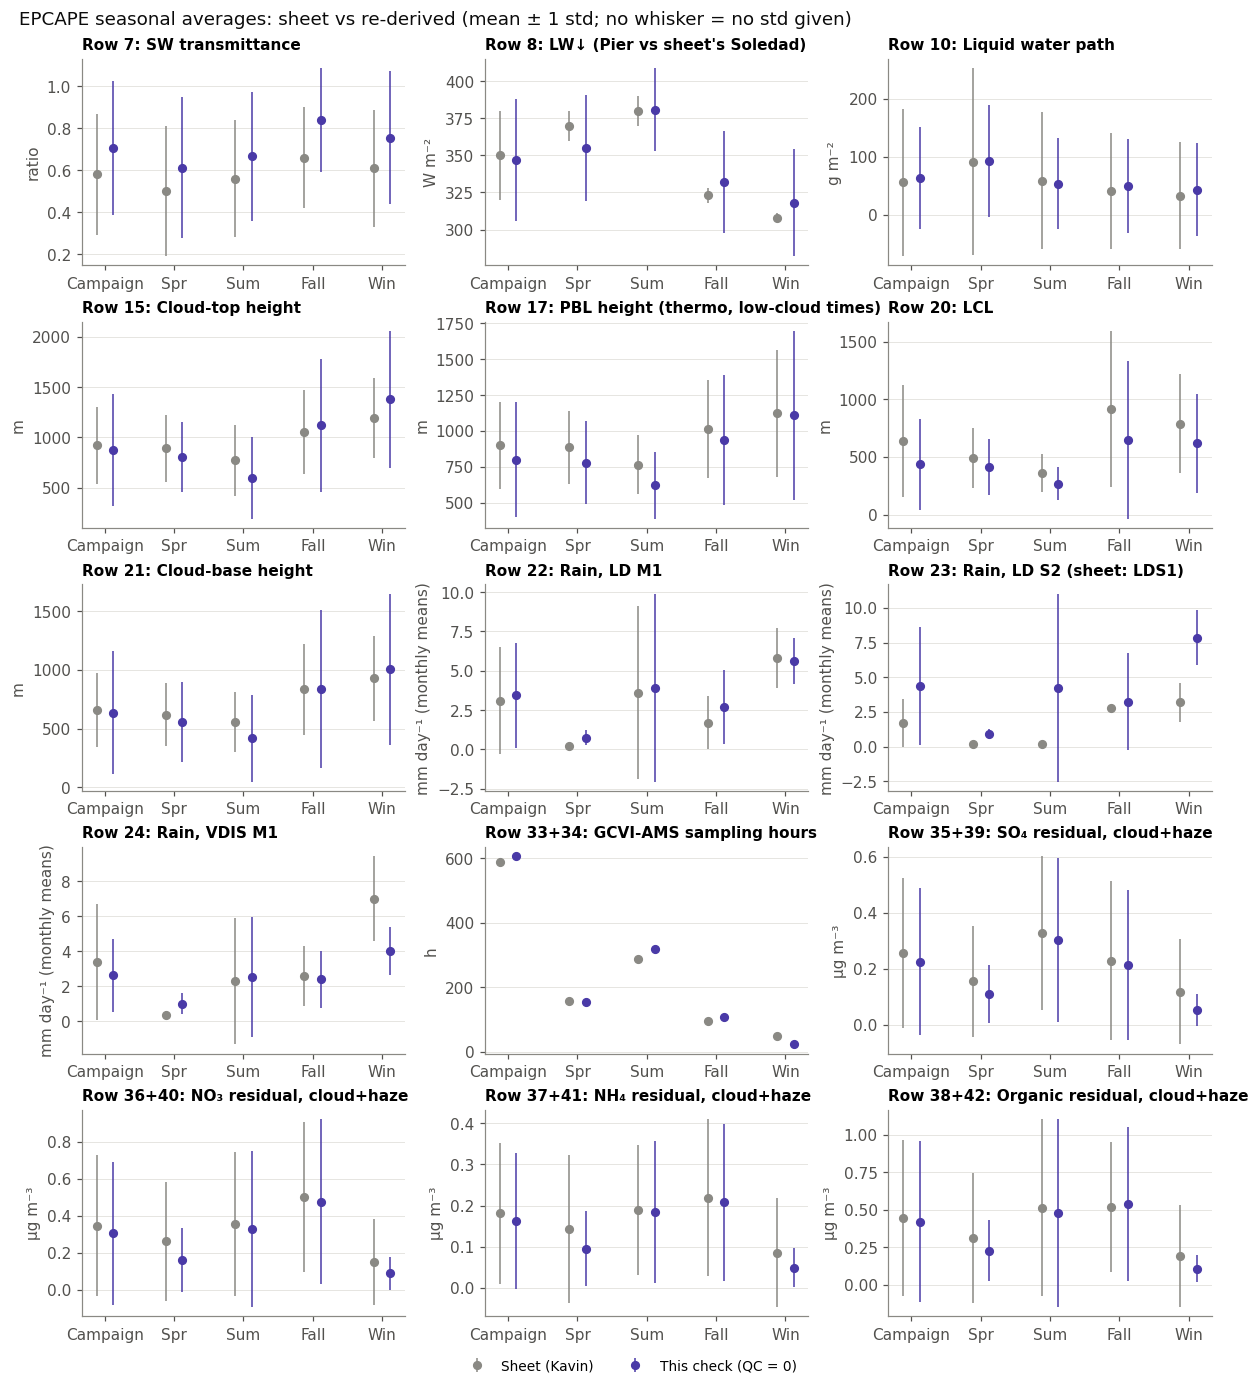

In [20]:
# --- Summary figure: sheet vs this check, one panel per row ------------------
# Grey = the sheet (reference); violet = this check (categorical slot 7, so the
# blue/orange/aqua instrument identities used in other EPCAPE figures stay unique).
SHEET_COLOR, OURS_COLOR = INK_3, "#4a3aa7"
PANELS = {  # sheet row -> (short title, y label)
    "7": ("SW transmittance", "ratio"), "8": ("LW↓ (Pier vs sheet's Soledad)", "W m⁻²"),
    "10": ("Liquid water path", "g m⁻²"), "15": ("Cloud-top height", "m"),
    "17": ("PBL height (thermo, low-cloud times)", "m"), "20": ("LCL", "m"), "21": ("Cloud-base height", "m"),
    "22": ("Rain, LD M1", "rain"), "23": ("Rain, LD S2 (sheet: LDS1)", "rain"), "24": ("Rain, VDIS M1", "rain"),
    "33+34": ("GCVI-AMS sampling hours", "h"), "35+39": ("SO₄ residual, cloud+haze", "µg m⁻³"),
    "36+40": ("NO₃ residual, cloud+haze", "µg m⁻³"), "37+41": ("NH₄ residual, cloud+haze", "µg m⁻³"),
    "38+42": ("Organic residual, cloud+haze", "µg m⁻³"),
}
RAIN_UNITS = {"A": "mm h⁻¹", "B": "mm h⁻¹ (event mean)", "C": "mm per event", "D": "mm day⁻¹",
              "E": "mm per wet hour", "F": "mm day⁻¹ (monthly means)", "G": "mm h⁻¹ (monthly means)"}
rows_to_plot = [r for r in PANELS if r in set(primary["sheet_row"])]
ncol = 3
nrow = int(np.ceil(len(rows_to_plot) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(11, 2.5 * nrow), constrained_layout=True)
x = np.arange(len(S.SEASON_ORDER))
for ax, r in zip(axes.flat, rows_to_plot):
    p = primary[primary["sheet_row"] == r].set_index("season").loc[S.SEASON_ORDER]
    ax.errorbar(x - 0.12, p["table_mean"], yerr=p["table_std"], fmt="o", color=SHEET_COLOR, ms=5,
                elinewidth=1, capsize=0, label="Sheet (Kavin)")
    ax.errorbar(x + 0.12, p["ours_mean"], yerr=p["ours_std"], fmt="o", color=OURS_COLOR, ms=5,
                elinewidth=1, capsize=0, label="This check (QC = 0)")
    title, ylabel = PANELS[r]
    ylabel = RAIN_UNITS.get(BEST_RAIN, "") if ylabel == "rain" else ylabel
    ax.set_title(f"Row {r}: {title}", loc="left", fontsize=10)
    ax.set_ylabel(ylabel, color=INK_2)
    ax.set_xticks(x, ["Campaign", "Spr", "Sum", "Fall", "Win"])
    ax.grid(axis="x", visible=False)
handles, labels = axes.flat[0].get_legend_handles_labels()
spare = list(axes.flat)[len(rows_to_plot):]
for ax in spare:
    ax.axis("off")
if spare:  # legend in the first empty panel slot ...
    spare[0].legend(handles, labels, loc="center", frameon=False, fontsize=10)
else:  # ... or below the panels
    fig.legend(handles, labels, loc="outside lower center", ncol=2, frameon=False)
fig.suptitle("EPCAPE seasonal averages: sheet vs re-derived (mean ± 1 std; no whisker = no std given)",
             x=0.01, ha="left", fontsize=12, color=INK)
fig.savefig(OUT_DIR / "seasonal_averages_check.png", bbox_inches="tight")
plt.show()

## 12. Findings to report back

*Written from the run recorded in this notebook (2026-10-06; QC = 0 throughout). Every number comes from the tables above. Percentages are (this check − sheet) / sheet, on the means.*

**Reproduced, with the definition stated**

| Row | Quantity | Campaign: this check vs sheet | Remarks |
|---|---|---|---|
| 8 | LW↓ | 347 vs 350 W m⁻² (−1 %); seasons within 4 % | Pier pyrgeometer vs the sheet's Soledad ("From Lubin"). The sheet's 3–10 W m⁻² stds are the spread of **monthly means**; 5-min values spread by 28–36 W m⁻². |
| 10 | LWP | 63 vs 56 g m⁻² (+13 %); spring identical, other seasons −8 to +33 % | MWRRET, rain-screened. Without the rain screen the winter mean is 3.5× the sheet's. MWRLOS gives 59 g m⁻² (+5 %). |
| 15 | Cloud top | 876 vs 920 m (−5 %); summer −23 %, winter +15 % | KAZR-ARSCL lowest layer ≤ 3 km |
| 17 | PBL height | 801 vs 899 m (−11 %); seasons −1 to −19 % | Only when restricted to times with a low cloud overhead. All times: 656 m (−27 %; fall −55 %). The table should state the conditioning. |
| 21 | Cloud base | 637 vs 661 m (−4 %); summer −24 % | Ceilometer ≤ 3 km. Our spread is 1.3–1.8× the sheet's in every season. |
| 22 | Rain, LD M1 | 3.4 vs 3.1 (+11 %); summer +9 %, winter −3 % | Reproduced only as the **monthly mean of the daily accumulation on rain days, in mm day⁻¹, with std across months**. The sheet's "mm/hr" is not the unit of these numbers. Spring is 0.73 vs 0.2. |
| 33+34 | GCVI-AMS hours | 605 vs 588 h (+3 %); winter 23 vs 49 h | Cloud + haze together (the split needs FM-120 data) |
| 35–42 | Residual SO₄, NO₃, NH₄, Org | −6 to −12 % (campaign); summer and fall within 8 % | AMS behind GCVI ÷ EF (≈ 5), against the hour-weighted cloud + haze rows. Spring is 27–39 % lower and winter 40–57 % lower. |

**Systematic differences to ask Kavin about**

* **Row 7, SW transmittance:** this check is 19–27 % higher in every season, with the same spread. Dividing instead by top-of-atmosphere irradiance gives values 7–11 % *below* the sheet. If the numerator is the same SKYRAD irradiance, the sheet's clear-sky model must equal 0.89–0.93 × TOA. RADFLUX's measured clear sky at the Pier is 0.73–0.76 × TOA, and a sea-level clear sky near 0.9 × TOA is implausible. The Atwater & Ball inputs (aerosol, water vapour) or the numerator should be checked. As it stands, the sheet's transmittances are probably biased low.
* **Row 20, LCL:** SONDEPARAM's surface-parcel LCL and an independent Romps (2017) calculation agree with each other (median difference 16 m over 1,081 launches) but are 16–32 % below the sheet. SONDEPARAM's mixed-layer-parcel LCL is 21–102 % above it. The sheet presumably used a different starting level or averaging layer.
* **Row 23, rain at "LDS1":** no reading reproduces it. The sheet's summer value of 0.21 is far below the 4.2 mm day⁻¹ the Mt. Soledad Parsivel recorded, which includes Hurricane Hilary on 20 Aug 2023. Its fall value has no std, i.e. one sample. The record behind this row looks incomplete. (ARM has no S1 facility for EPCAPE; the Soledad disdrometer is S2.)
* **Row 24, rain, VDIS:** campaign −23 %, winter −42 %, other seasons within ±9 % except spring. The VDIS misses parts of several storms the Parsivel records (e.g. 21 Aug 2023: 14.6 mm vs 0 mm), so its totals depend on how gaps are treated.

**Not checkable with available data:** rows 18 (PBLH-MPL) and 19 (BL-Depth, Miller), whose sources aren't identified and which have no ARM product for EPCAPE; and rows 25–30 and 54–55, which need FM-120 data that are not public.

**Corrections to the sheet** (Section 0): H34 should be ~48 h, not 5.0×10². Rows 35–42 are mass concentrations (µg m⁻³), not mass fractions. B7's unit is a fraction, not %. B25/B28 should be cm⁻³. Rows 26, 29 and 35–42 need units. E18 and H19 have typos. Rows 7–8 are at the Pier, not Soledad. Rows 22–24 are mm day⁻¹ (monthly means), not mm/hr.